In [2]:
# Uncomment this cell if running notebook in Google Colab
!pip install osmnx hvplot geoviews

# Import python libraries
import osmnx as osm
import geopandas as gpd
import matplotlib.pyplot as plt
import hvplot.pandas
import geoviews
import holoviews as hv

/opt/conda/lib/python3.11/site-packages/dask/dataframe/__init__.py:31: FutureWarning: 
Dask dataframe query planning is disabled because dask-expr is not installed.

You can install it with `pip install dask[dataframe]` or `conda install dask`.
This will raise in a future version.

  warnings.warn(msg, FutureWarning)


In [ ]:
# Look for CU Boulder using geocode_to_gdf
csu_gdf = osm.geocode_to_gdf("Colorado State University")
csu_gdf

,geometry,bbox_north,bbox_south,bbox_east,bbox_west,place_id,osm_type,osm_id,lat,lon,class,type,place_rank,importance,addresstype,name,display_name
0,"MULTIPOLYGON (((-105.10968 40.57637, -105.1091...",40.594754,40.552786,-105.072182,-105.109676,329372368,relation,8539568,40.570657,-105.085399,amenity,university,30,0.547321,amenity,Colorado State University,"Colorado State University, Isotope Drive, Fort..."


<Axes: >

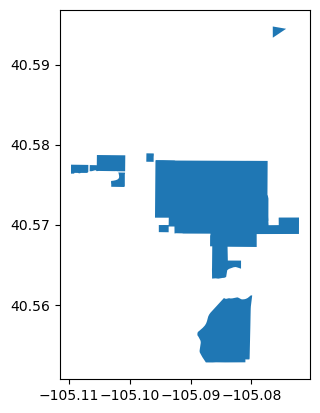

In [ ]:
# Plot the boundary
csu_gdf.plot()

In [9]:
# Look for everything labeled 'University' within 1000m of an address
csu_uni = osm.features_from_address(
    'Fort Collins, Colorado, USA',
    {'amenity': ['university']},
    dist=1000) # adjust dist= to find more buildings
csu_uni

,,geometry,nodes,name,ways,amenity,contact:website,short_name,type,wikidata,wikipedia
element_type,osmid,,,,,,,,,,
relation,8539568,"MULTIPOLYGON (((-105.10281 40.57868, -105.1007...","[[[8993897518, 9198191072, 8994516033, 2382933...",Colorado State University,"[208623822, 971723614, 386388522, 386113581, 9...",university,https://www.colostate.edu/,CSU,multipolygon,Q1111640,en:Colorado State University


In [10]:
# Plot CSU boundary
csu_map = csu_gdf.reset_index().hvplot(
    # Givethe map a descriptive title
    title="Colorado State University, Fort Collins, CO",
    # Add a basemap
    geo=True, tiles='EsriImagery',
    # Change the colors
    fill_color='white', fill_alpha=0.2,
    line_color='skyblue', line_width=5,
    # Change the image size
    frame_width=400, frame_height=400)

# Save the map as a file to put on the web
hv.save(csu_map, 'csu.html')

# Display the map
csu_map

:Overlay
   .WMTS.I     :WMTS   [Longitude,Latitude]
   .Polygons.I :Polygons   [Longitude,Latitude]